In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
import os
import shlex
import sys
from joblib import load
import glob 
import re


## loss and accuracy

In [2]:
res_dirs = "results_pairs_min7_max7/logpolar"
res_files = glob.glob(os.path.join(res_dirs, "results_*.pkl"))
res_files

['results_pairs_min7_max7/logpolar/results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl',
 'results_pairs_min7_max7/logpolar/results_rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl']

In [3]:
res_lists = {}
shortmodelnames = dict(zip(res_files,
                           ["embedding","one-hot"]))
for rf,sn in shortmodelnames.items():
    res = load(rf)
    res["dataset"] = pd.Categorical(res["dataset"], categories = ["train","validation","ood"],ordered=True)
    res_lists[sn] = res
        
    
# we have 300+1 epochs in total
loss_cols = ['count map loss','count num loss','dist map loss']
acc_cols = ['accuracy count']

res.columns

Index(['full map loss', 'dist map loss', 'count map loss', 'count num loss',
       'dist num loss', 'all num loss', 'shape loss', 'accuracy count',
       'accuracy dist', 'accuracy all', 'epoch', 'dataset', 'accuracy map',
       'viewing', 'test shapes', 'test lums'],
      dtype='object')

In [4]:
list(res_lists.keys())

['embedding', 'one-hot']

In [4]:
# load the dataset files to get the information of pairs
ds_dir = "datasets/image_sets_min_max_pairs_min7_max7"
file_pat = {
    "train":      "*_pair-train_*_lum[[]0.1, 0.4, 0.7[]]*_100000.pkl",
    "validation": "*_pair-train_*_lum[[]0.1, 0.4, 0.7[]]*_5000.pkl",
    "OODlum":     "*_pair-train_*_lum[[]0.3, 0.6, 0.9[]]*_5000.pkl",
    "OODshape":   "*_pair-test_*_lum[[]0.1, 0.4, 0.7[]]*_5000.pkl",
    "OODboth":    "*_pair-test_*_lum[[]0.3, 0.6, 0.9[]]*_5000.pkl"
}
ds_paths = {}
for k, v in file_pat.items():
    files = glob.glob(os.path.join(ds_dir, v))
    assert len(files) == 1, f"Expected exactly one file for {k}, found {len(files)}"
    ds_paths[k] = files[0]

pairs_list_byds = {}
unique_pairs = {}
for dsname, ds_path in ds_paths.items():
    ds = load(ds_path)

    pairs = []
    for x in ds["shape_map"]:
        labels, counts = np.unique_counts(list(x.values()))
        pairs.append(f"{labels[0]}_{labels[1]}")
    pairs_list_byds[dsname] = pairs
    if dsname in ["train","OODshape"]:
        unique_pairs[dsname] = np.unique(pairs)

# make sure train and OODshape does not have the same pairs
assert len(set(unique_pairs["train"]).intersection(set(unique_pairs["OODshape"]))) == 0

# merge OOD in the order of [OODshape, OODlum, OODboth]
pairs_list_mergeOOD = {
    "train": pairs_list_byds["train"],
    "validation": pairs_list_byds["validation"],
    "ood": pairs_list_byds["OODshape"] + pairs_list_byds["OODlum"] + pairs_list_byds["OODboth"]
}

In [5]:
dsdf = res[res['dataset']=='ood'].copy()
#ood_shape_free, ood_lum_free, ood_both_free
res['dataset'].unique()

['train', 'validation', 'ood']
Categories (3, object): ['train' < 'validation' < 'ood']

/tmp/ipykernel_5435/67343160.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_5435/67343160.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


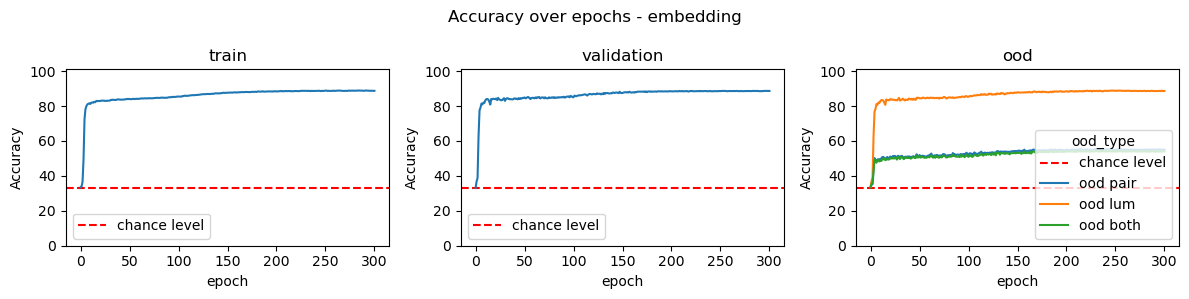

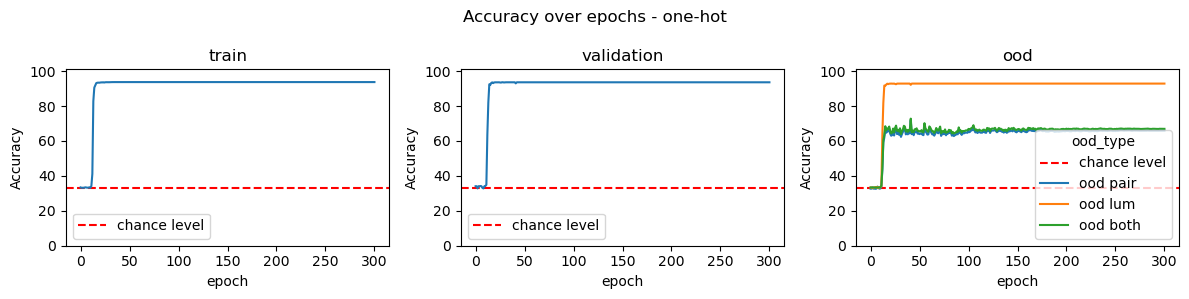

In [6]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        chance_level = 100 * (1/3)
        ax_acc[j].axhline(chance_level, color='red', linestyle='--', label='chance level')
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()            
            dsdf['ood_type'] = ["ood pair"] * 301 + ["ood lum"] * 301 + ["ood both"] * 301
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', hue='ood_type', ax=ax_acc[j])
            

        else:
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', ax=ax_acc[j])
        
        ax_acc[j].set_ylim(0, 101)        
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Accuracy')

    fig_acc.suptitle(f'Accuracy over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_5435/2228785670.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_5435/2228785670.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


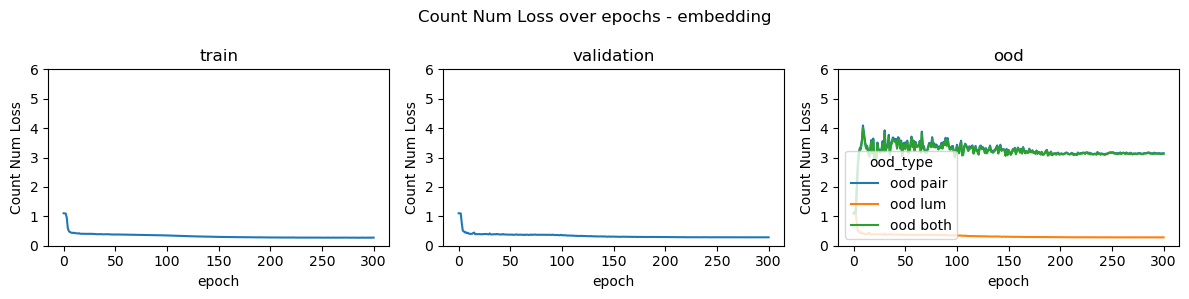

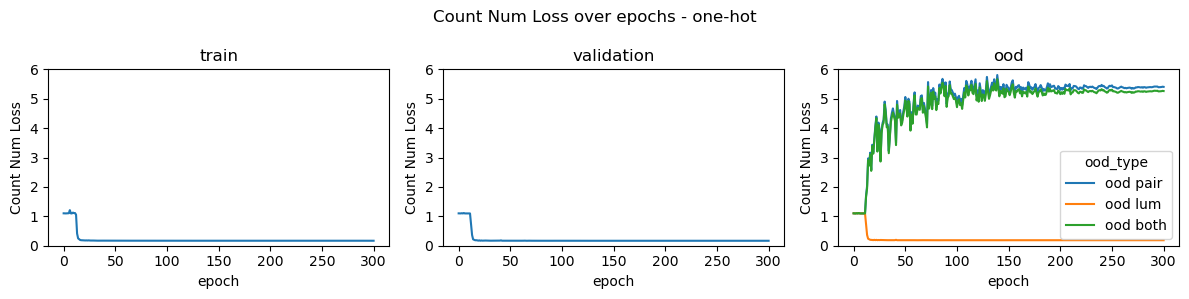

In [7]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['ood_type'] = ["ood pair"] * 301 + ["ood lum"] * 301 + ["ood both"] * 301
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', ax=ax_acc[j])

        ax_acc[j].set_ylim(0, 6)
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Num Loss')

    fig_acc.suptitle(f'Count Num Loss over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_5435/1072415849.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_5435/1072415849.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


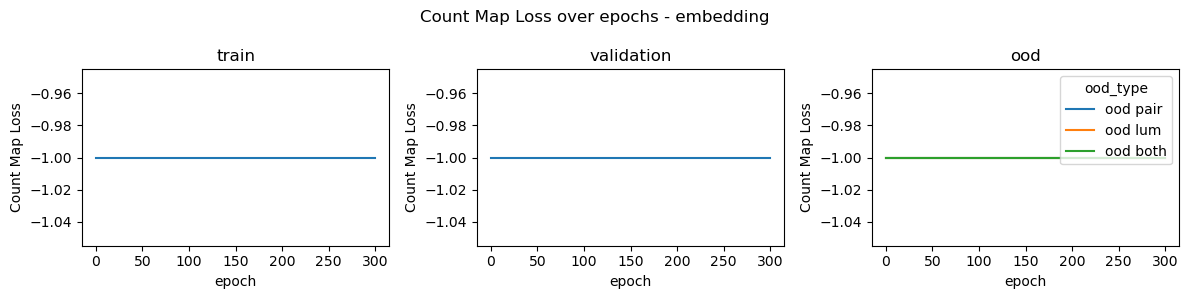

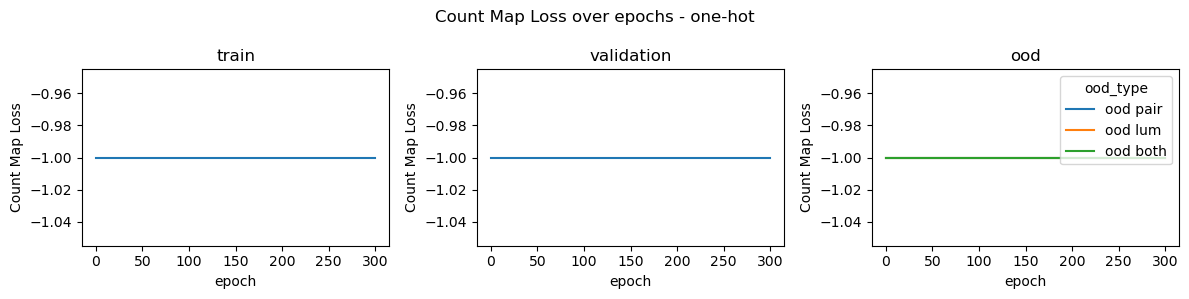

In [8]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['ood_type'] = ["ood pair"] * 301 + ["ood lum"] * 301 + ["ood both"] * 301
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', ax=ax_acc[j])

        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Map Loss')

    fig_acc.suptitle(f'Count Map Loss over epochs - {rsname}')
    plt.tight_layout()

## confusion matrix

In [10]:
conf_dir = res_dirs
conf_files = glob.glob(os.path.join(conf_dir, "confusion_*.npy"))
conf_files = [f for f in conf_files if "at_" not in f]
conf_files

['results_pairs_min7_max7/logpolar/confusion_rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.npy',
 'results_pairs_min7_max7/logpolar/confusion_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.npy']

In [11]:
conf_lists = {}
shortconfnames = dict(zip(conf_files,
                           ["one-hot","embedding"]))
        
for conf_file,sn in shortconfnames.items():
    conf_lists[sn] = np.load(conf_file)

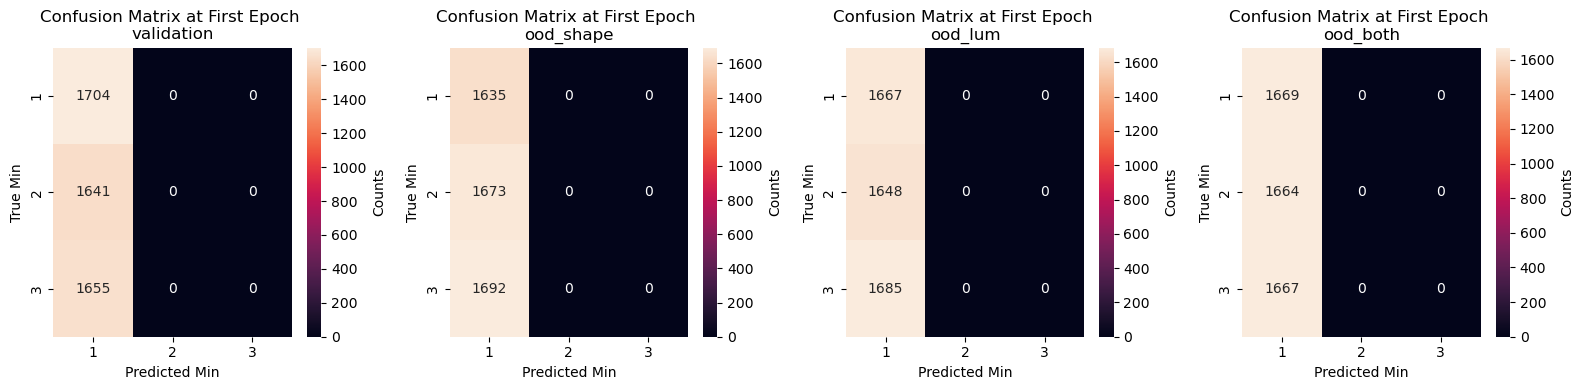

In [12]:
conf = conf_lists["one-hot"]
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[0])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at First Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

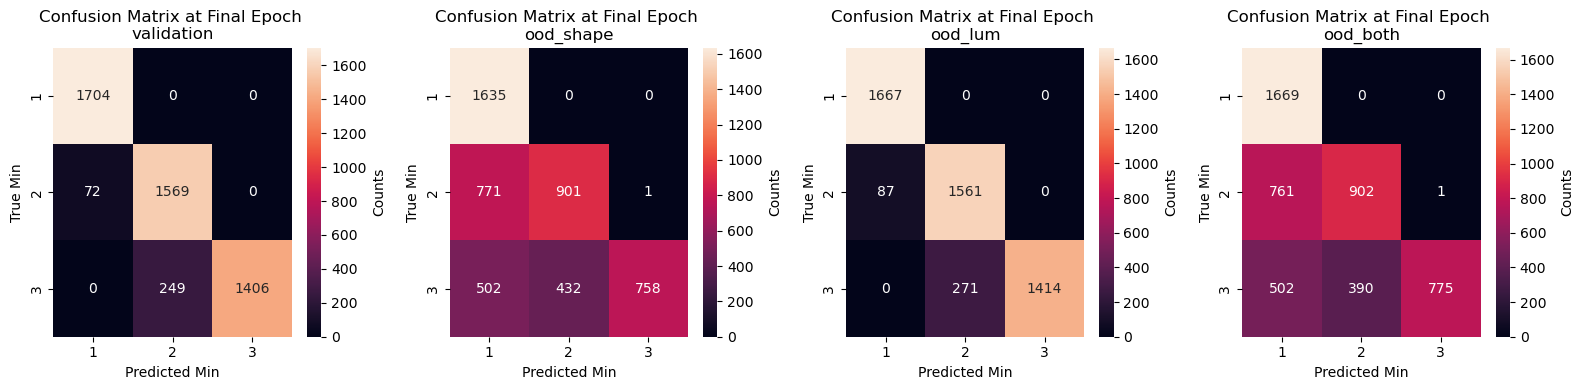

In [13]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

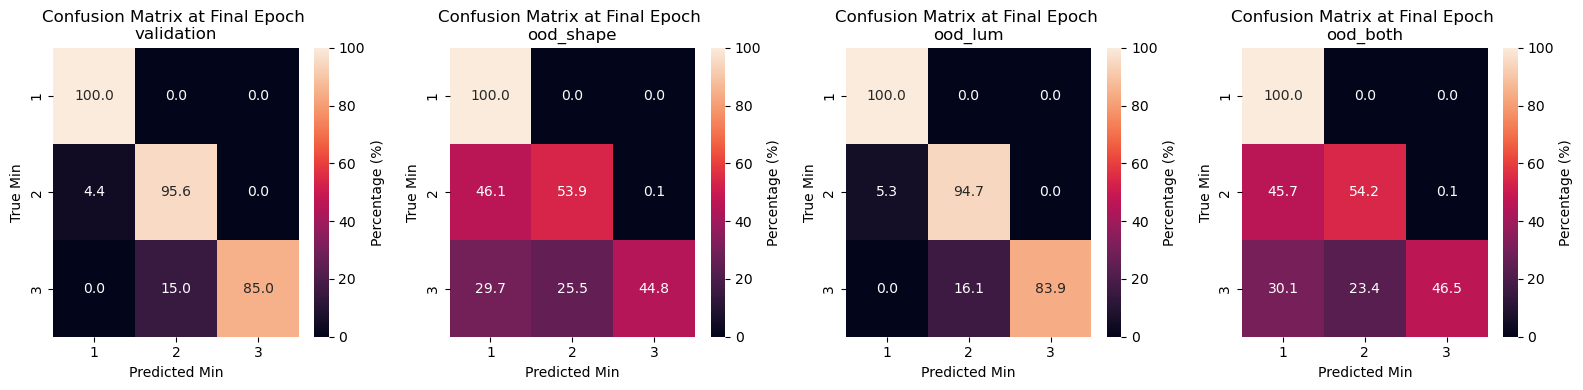

In [14]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c*100 / c.sum(axis=1, keepdims=True), annot=True, fmt=".1f", ax=ax, 
                cbar_kws={'label': 'Percentage (%)'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

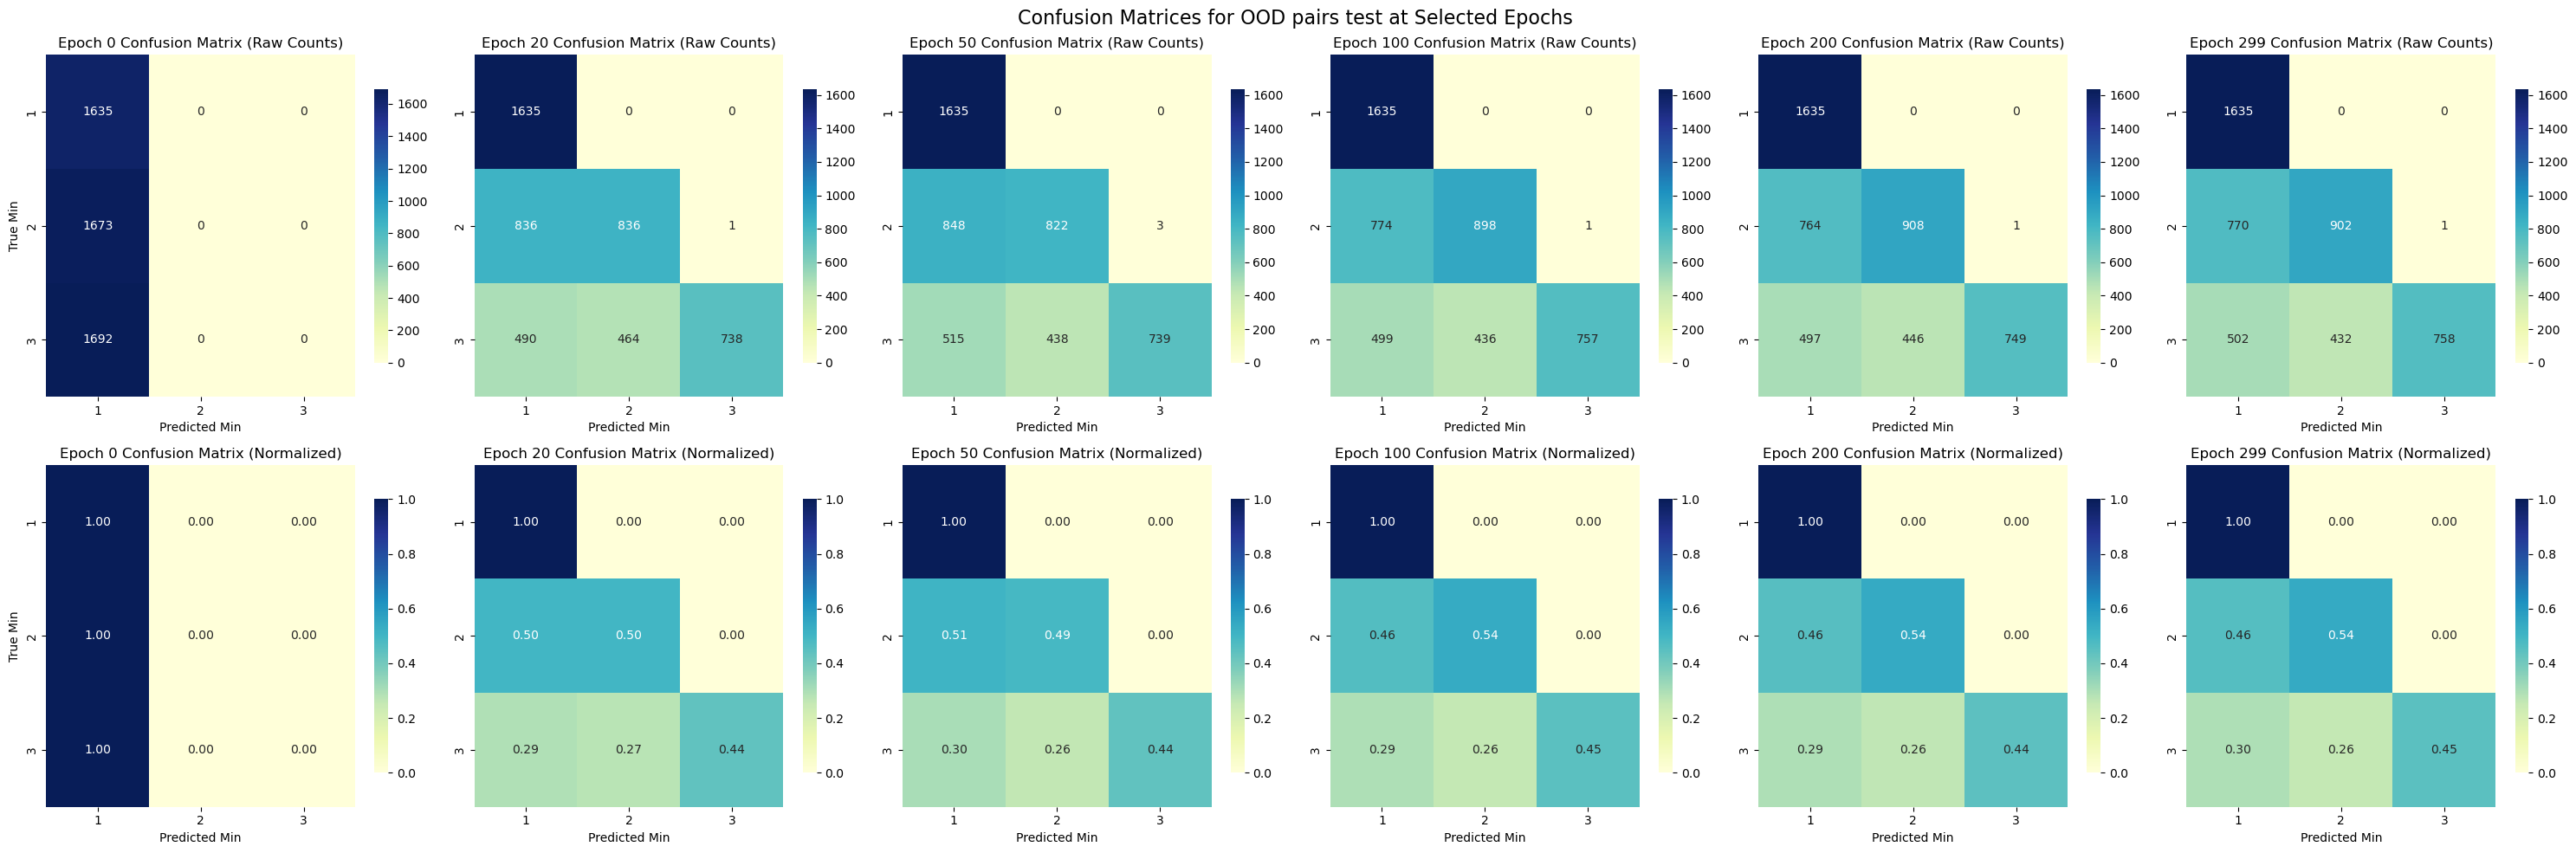

In [18]:
conf = conf_lists["one-hot"]
checkpoints = np.array([0, 20, 50,100,200, 299])  # zero-based indices
n_checkpoints = len(checkpoints)

conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
plt_conf = "ood_shape"
plt_loc = conf_names.index(plt_conf)
# display two rows, one the raw confusion matrix, one normalized, with heatmaps
fig, axes = plt.subplots(2, n_checkpoints, figsize=(5*n_checkpoints, 10))
for i, cp in enumerate(checkpoints):
    ax = axes[0, i] if n_checkpoints > 1 else axes[0]
    c = conf[cp][plt_loc]
    sns.heatmap(c, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
                cbar_kws={"shrink": 0.8},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Epoch {cp} Confusion Matrix (Raw Counts)')

    axn = axes[1, i] if n_checkpoints > 1 else axes[1]
    sns.heatmap(c / c.sum(axis=1, keepdims=True), annot=True, fmt='.2f', cmap='YlGnBu', ax=axn,
                cbar_kws={"shrink": 0.8},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    axn.set_title(f'Epoch {cp} Confusion Matrix (Normalized)')

    if i == 0:
        ax.set_ylabel('True Min')
        axn.set_ylabel('True Min')
    ax.set_xlabel('Predicted Min')
    axn.set_xlabel('Predicted Min')

fig.suptitle(f'Confusion Matrices for {plt_conf if plt_conf!="ood_shape" else "OOD pairs"} test at Selected Epochs', fontsize=16)
plt.tight_layout()

# Saved Trained model

In [38]:
import torch
model_dir = "models_pairs_min7_max7/logpolar"
model_file = glob.glob(os.path.join(model_dir, "pretrained_ventral*.pt"))[0]
model_file = glob.glob(os.path.join(model_dir, "rnn_classifier2stream*.pt"))[0]
print(model_file)
ventral_model_file = glob.glob(os.path.join(model_dir,"ventral","*.pt"))[0]
ventral_model_file
saved_model = torch.load(model_file)


models_pairs_min7_max7/logpolar/rnn_classifier2stream_hsize-1024_input-both_onehot_num7-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEFGHJ_min_gw6_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_ep-300.pt


/tmp/ipykernel_109722/768239375.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_model = torch.load(model_file)


In [39]:
saved_model.rnn

RNN(
  (act_fun): LeakyReLU(negative_slope=0.1)
  (i2h): Linear(in_features=2048, out_features=1024, bias=True)
  (h2o): Linear(in_features=1024, out_features=1024, bias=True)
)

In [40]:
# ------------------------
# After training: inspect learned weights (quick print)
# ------------------------
model_weights = {}
print("\nModel parameter summary (name, shape, L2 norm):")
for name, p in saved_model.named_parameters():
    print(f"{name} {tuple(p.shape)}  L2={p.detach().cpu().norm().item():.4f}")
    model_weights[name] = p.detach().cpu().numpy()




Model parameter summary (name, shape, L2 norm):
pix_embedding.weight (512, 25)  L2=13.4535
pix_embedding.bias (512,)  L2=1.9350
xy_embedding.weight (512, 2)  L2=11.5177
xy_embedding.bias (512,)  L2=7.0180
joint_embedding.weight (1024, 1024)  L2=32.0591
joint_embedding.bias (1024,)  L2=0.7304
rnn.i2h.weight (1024, 2048)  L2=68.9524
rnn.i2h.bias (1024,)  L2=1.3641
rnn.h2o.weight (1024, 1024)  L2=56.8948
rnn.h2o.bias (1024,)  L2=1.3731
map_readout.weight (36, 1024)  L2=6.7191
map_readout.bias (36,)  L2=0.2845
num_readout.weight (3, 36)  L2=0.6856


Text(-0.08, 0.25, ' OOD')

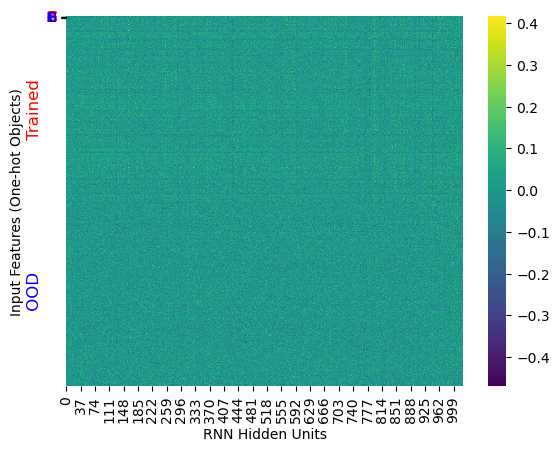

In [41]:
ax = sns.heatmap(model_weights['rnn.i2h.weight'].T, cmap='viridis',
                yticklabels=['A','B','C','D','E','F','G','H'])
ax.set_xlabel('RNN Hidden Units')
ax.set_ylabel('Input Features (One-hot Objects)\n  ')
# Color each y-tick label
for ticklabel, color in zip(plt.gca().get_yticklabels(), ['red']*4 + ['blue']*4):
    ticklabel.set_color(color)
ax.text(-0.08, 0.75, 'Trained', color='red', fontsize=12,
        ha='center', va='center', rotation='vertical', transform=ax.transAxes)
ax.text(-0.08, 0.25, ' OOD', color='blue', fontsize=12,
        ha='center', va='center', rotation='vertical', transform=ax.transAxes)